# Milan Airbnb - Data Preparation Pipeline

This notebook performs the complete ETL pipeline for Milan Airbnb data:
1. Load raw data from Inside Airbnb
2. Clean listings, calendar, and reviews
3. Create spatial data structures
4. Spatial join listings to neighbourhoods
5. Aggregate metrics to neighbourhood level
6. Quality checks and visualization

In [8]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import logging

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
logger = logging.getLogger(__name__)

from src.config import (
    INPUT_FILES, OUTPUT_FILES, CRS_WEB, CRS_METRIC,
    LISTINGS_SAMPLE_SIZE, RANDOM_SEED, CITY_NAME
)
from src.io import load_csv, load_geojson, save_parquet, save_geojson
from src.cleaning import clean_calendar, clean_listings
from src.reviews import clean_and_aggregate_reviews
from src.spatial import (
    listings_to_geodataframe, clean_neighbourhoods,
    spatial_join_listings_neighbourhoods, aggregate_to_neighbourhoods
)
from src.qc import (
    check_unique_ids, check_geometry_validity, check_crs,
    check_price_range, print_qc_report
)

ImportError: cannot import name 'print_qc_report' from 'src.qc' (/Users/filippostanghellini/GitHub/Geopsatial-project/src/qc.py)

## Step 1: Load Raw Data

In [9]:
listings_raw = load_csv(INPUT_FILES['listings_detailed'])
calendar_raw = load_csv(INPUT_FILES['calendar_detailed'])
reviews_raw = load_csv(INPUT_FILES['reviews_detailed'])
neighbourhoods_raw = load_geojson(INPUT_FILES['neighbourhoods_geojson'])

print(f"Listings: {len(listings_raw)} rows")
print(f"Calendar: {len(calendar_raw)} rows")
print(f"Reviews: {len(reviews_raw)} rows")
print(f"Neighbourhoods: {len(neighbourhoods_raw)} polygons")

INFO: Loading CSV: /Users/filippostanghellini/GitHub/Geopsatial-project/data/original/listings.csv
INFO: Loading CSV: /Users/filippostanghellini/GitHub/Geopsatial-project/data/original/calendar.csv
INFO: Loading CSV: /Users/filippostanghellini/GitHub/Geopsatial-project/data/original/reviews.csv
INFO: Loading GeoJSON: /Users/filippostanghellini/GitHub/Geopsatial-project/data/original/neighbourhoods.geojson


Listings: 22933 rows
Calendar: 8376020 rows
Reviews: 981739 rows
Neighbourhoods: 88 polygons


## Step 2: Clean Calendar

In [ ]:
calendar_clean = clean_calendar(calendar_raw)
save_parquet(calendar_clean, OUTPUT_FILES['calendar_clean'])
print(f"Calendar cleaned and saved: {len(calendar_clean)} rows")

INFO: Cleaning calendar data
INFO: Calendar cleaned: 8376020 rows
INFO: Saving Parquet: /Users/filippostanghellini/GitHub/Geopsatial-project/data/processed/calendar_clean.parquet


Calendar cleaned and saved: 8376020 rows


## Step 3: Clean Listings

In [10]:
listings_clean = clean_listings(listings_raw)
save_parquet(listings_clean, OUTPUT_FILES['listings_clean'])
print(f"Listings cleaned and saved: {len(listings_clean)} rows")
listings_clean.head()

INFO: Cleaning listings data
INFO: Dropped 2401 listings with price outliers
INFO: Dropped 0 listings with invalid coordinates
INFO: Listings cleaned: 20532 rows
INFO: Saving Parquet: /Users/filippostanghellini/GitHub/Geopsatial-project/data/processed/listings_clean.parquet


Listings cleaned and saved: 20532 rows


,listing_id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,23986,https://www.airbnb.com/rooms/23986,20250922033939,2025-09-24,city scrape,""" Characteristic Milanese flat""",I look forward to welcoming you in my flat; it...,NaN,https://a0.muscache.com/pictures/623d63f8-56cf...,95941,...,4.73,4.69,4.46,NaN,f,1,1,0,0,0.16
2,46536,https://www.airbnb.com/rooms/46536,20250922033939,2025-09-24,city scrape,Nico & Cinzia's Pink Suite!,Over the international fair in April we rent f...,"Flat It's located in north side of milan, jus...",https://a0.muscache.com/pictures/4eb8e0f5-e17b...,138683,...,4.92,4.34,4.58,IT015209C2BBKGCMT7,f,1,1,0,0,0.23
3,84741,https://www.airbnb.com/rooms/84741,20250922033939,2025-09-24,city scrape,Nice room with private bathroom,Independent room with private bathroom.<br />C...,"It may seem a peripheral zone and bare, but ju...",https://a0.muscache.com/pictures/0b34089b-4d58...,443989,...,4.88,4.18,4.64,"I applied for a CIN, but haven’t received it yet",f,3,1,2,0,3.94
4,88130,https://www.airbnb.com/rooms/88130,20250922033939,2025-09-24,city scrape,Great comfortable & quite APT. x 4 people!,Our bright and comfortable apartment for 3+ 1 ...,NaN,https://a0.muscache.com/pictures/606790/408e10...,481475,...,5.00,4.43,4.71,NaN,f,1,1,0,0,0.04
5,101087,https://www.airbnb.com/rooms/101087,20250922033939,2025-09-22,city scrape,"Flat "" Chiesa Rossa2 in Milan",NaN,ChiesaRossa is close to Naviglio Pavese and Da...,https://a0.muscache.com/pictures/2873561/d13d3...,530151,...,4.88,4.75,4.63,NaN,t,1,1,0,0,0.05


## Step 4: Clean and Aggregate Reviews

In [11]:
reviews_agg = clean_and_aggregate_reviews(reviews_raw)
save_parquet(reviews_agg, OUTPUT_FILES['reviews_listing_features'])
print(f"Reviews aggregated: {len(reviews_agg)} listings")

INFO: Cleaning and aggregating reviews
INFO: Reviews aggregated for 19522 listings
INFO: Saving Parquet: /Users/filippostanghellini/GitHub/Geopsatial-project/data/processed/reviews_listing_features.parquet


Reviews aggregated: 19522 listings


## Step 5: Create Spatial Data

In [12]:
gdf_listings = listings_to_geodataframe(listings_clean)
gdf_neighbourhoods = clean_neighbourhoods(neighbourhoods_raw)

print(f"Listings GeoDataFrame: {len(gdf_listings)} points")
print(f"Neighbourhoods GeoDataFrame: {len(gdf_neighbourhoods)} polygons")

INFO: Converting listings to GeoDataFrame
INFO: Cleaning neighbourhoods


Listings GeoDataFrame: 20532 points
Neighbourhoods GeoDataFrame: 88 polygons


## Step 6: Spatial Join

In [13]:
gdf_joined = spatial_join_listings_neighbourhoods(gdf_listings, gdf_neighbourhoods)
print(f"Joined listings: {len(gdf_joined)}")

INFO: Spatial join: listings -> neighbourhoods
INFO: Spatial join coverage: 100.0% (20532/20532)


Joined listings: 20532


## Step 7: Aggregate to Neighbourhood Level

In [14]:
neighbourhoods_enriched = aggregate_to_neighbourhoods(gdf_listings, gdf_neighbourhoods)
save_parquet(neighbourhoods_enriched, OUTPUT_FILES['neighbourhoods_enriched'])
save_geojson(neighbourhoods_enriched, OUTPUT_FILES['neighbourhoods_enriched_geojson'])
print(f"Neighbourhoods enriched: {len(neighbourhoods_enriched)}")
neighbourhoods_enriched.head()

INFO: Aggregating listings to neighbourhood level
INFO: Spatial join: listings -> neighbourhoods
INFO: Spatial join coverage: 100.0% (20532/20532)
INFO: Aggregated to 88 neighbourhoods
INFO: Saving Parquet: /Users/filippostanghellini/GitHub/Geopsatial-project/data/processed/neighbourhoods_enriched.parquet
INFO: Saving GeoJSON: /Users/filippostanghellini/GitHub/Geopsatial-project/data/processed/neighbourhoods_enriched.geojson
INFO: Created 88 records


Neighbourhoods enriched: 88


,neighbourhood,neighbourhood_group,geometry,area_km2,neighbourhood_cleansed,listing_count,median_price,mean_price,listing_density
0,SACCO,None,"MULTIPOLYGON (((9.12195 45.51602, 9.12163 45.5...",0.708393,SACCO,4.0,262.0,239.500000,5.646583
1,COMASINA,None,"MULTIPOLYGON (((9.16887 45.52396, 9.16804 45.5...",0.926713,COMASINA,30.0,85.5,123.400000,32.372475
2,STEPHENSON,None,"MULTIPOLYGON (((9.12932 45.50998, 9.12973 45.5...",0.560068,STEPHENSON,3.0,60.0,73.000000,5.356490
3,QT 8,None,"MULTIPOLYGON (((9.14368 45.48474, 9.14338 45.4...",1.024406,QT 8,41.0,84.0,101.853659,40.023190
4,ORTOMERCATO,None,"MULTIPOLYGON (((9.23739 45.45588, 9.23731 45.4...",1.402471,ORTOMERCATO,50.0,95.5,172.020000,35.651373


## Step 8: Create Sample for Webmap

In [15]:
sample = gdf_joined.sample(n=min(LISTINGS_SAMPLE_SIZE, len(gdf_joined)), random_state=RANDOM_SEED)
save_geojson(sample, OUTPUT_FILES['listings_points_enriched_sample'])
print(f"Sample created: {len(sample)} listings")

INFO: Saving GeoJSON: /Users/filippostanghellini/GitHub/Geopsatial-project/data/processed/listings_points_enriched_sample.geojson
INFO: Created 500 records


Sample created: 500 listings


## Step 9: Quality Checks

In [16]:
print("=" * 60)
print("QUALITY CHECKS")
print("=" * 60)

print("\n--- Listings ---")
check_unique_ids(listings_clean, 'listing_id')
check_price_range(listings_clean, 'price')

print("\n--- Listings GeoDataFrame ---")
check_geometry_validity(gdf_listings)
check_crs(gdf_listings, CRS_WEB)

print("\n--- Neighbourhoods ---")
check_geometry_validity(gdf_neighbourhoods)
check_crs(gdf_neighbourhoods, CRS_WEB)

print("\n" + "=" * 60)

INFO:   [PASS] Unique IDs: 20532
INFO:   [INFO] Price outliers (outside 10-10000): 0
INFO:   [PASS] All geometries valid
INFO:   [PASS] CRS: EPSG:4326
INFO:   [PASS] All geometries valid
INFO:   [PASS] CRS: EPSG:4326


QUALITY CHECKS

--- Listings ---

--- Listings GeoDataFrame ---

--- Neighbourhoods ---



## Step 10: Data Quality Visualizations

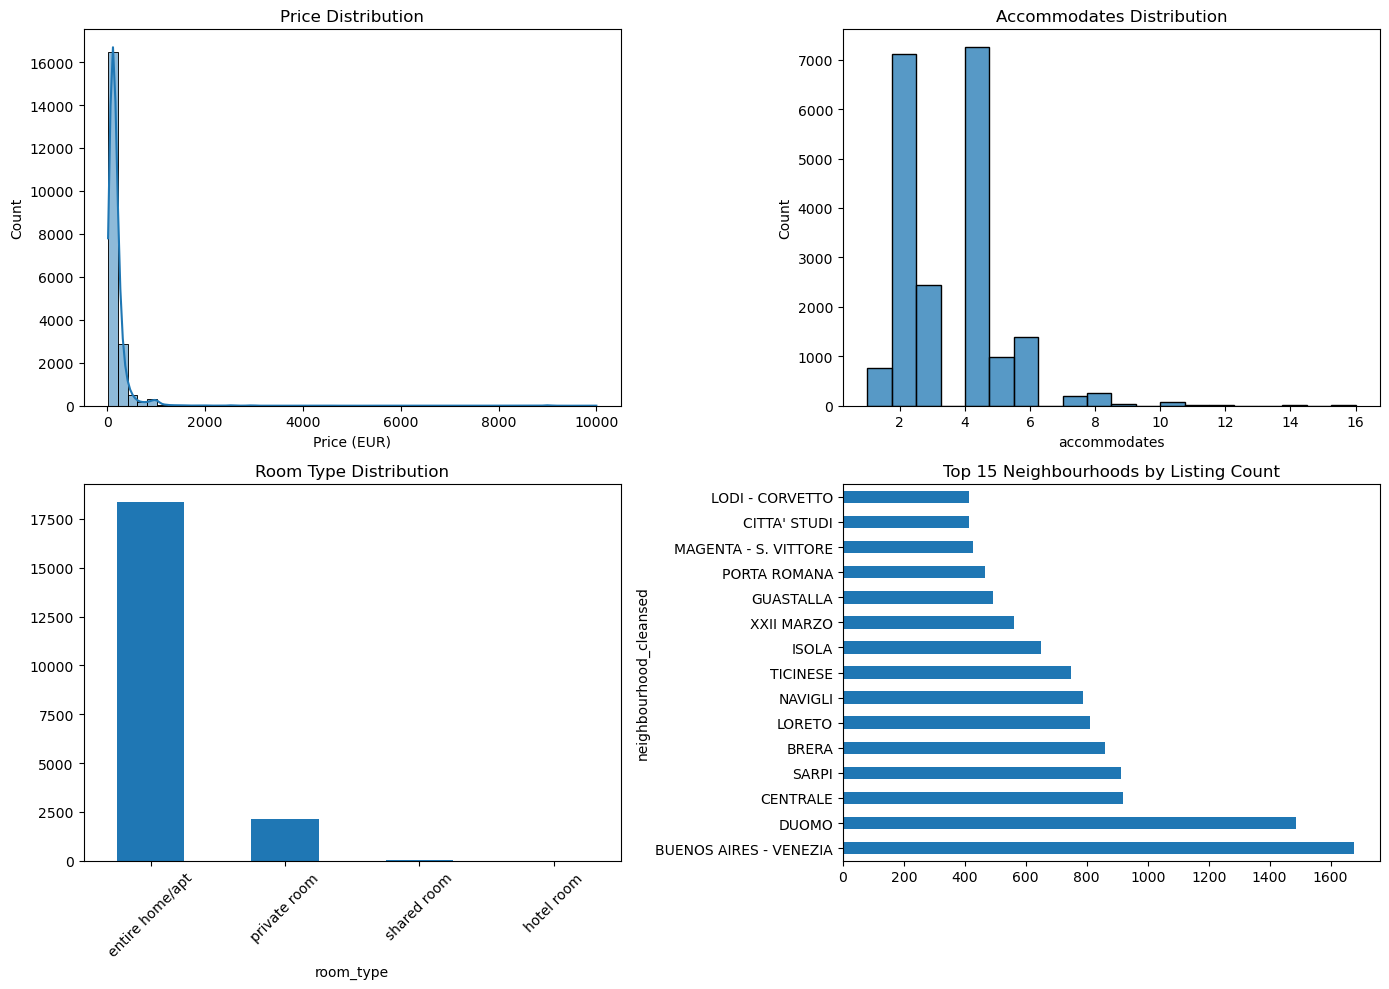

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(listings_clean['price'], bins=50, ax=axes[0, 0], kde=True)
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Price (EUR)')

if 'accommodates' in listings_clean.columns:
    sns.histplot(listings_clean['accommodates'], bins=20, ax=axes[0, 1])
    axes[0, 1].set_title('Accommodates Distribution')

if 'room_type' in listings_clean.columns:
    listings_clean['room_type'].value_counts().plot(kind='bar', ax=axes[1, 0])
    axes[1, 0].set_title('Room Type Distribution')
    axes[1, 0].tick_params(axis='x', rotation=45)

if 'neighbourhood_cleansed' in listings_clean.columns:
    top_neigh = listings_clean['neighbourhood_cleansed'].value_counts().head(15)
    top_neigh.plot(kind='barh', ax=axes[1, 1])
    axes[1, 1].set_title('Top 15 Neighbourhoods by Listing Count')

plt.tight_layout()
plt.savefig(project_root / 'reports' / 'figures' / '01_data_quality_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 11: Spatial Visualization

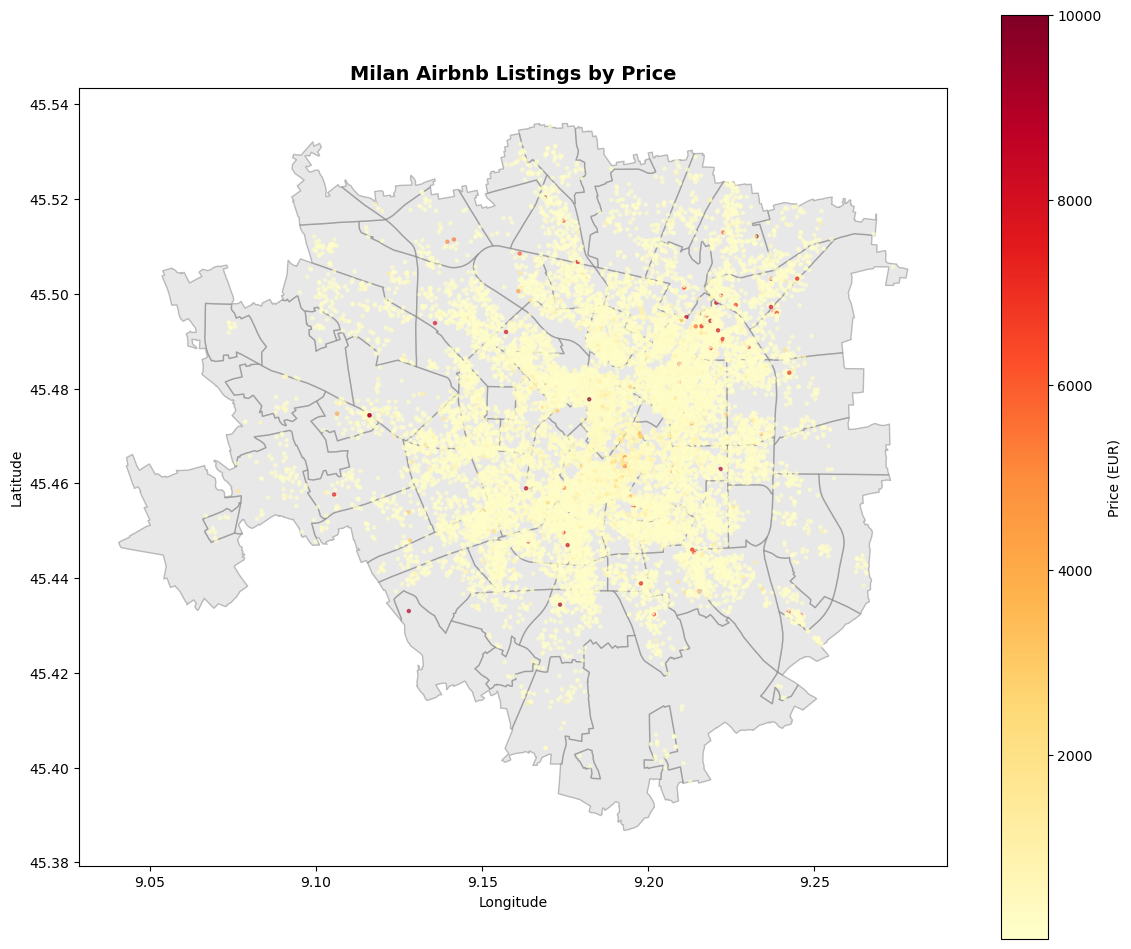

In [18]:
fig, ax = plt.subplots(figsize=(14, 12))

gdf_neighbourhoods.plot(ax=ax, facecolor='lightgray', edgecolor='gray', alpha=0.5)

if 'price' in gdf_listings.columns:
    gdf_listings.plot(
        ax=ax,
        column='price',
        cmap='YlOrRd',
        markersize=5,
        alpha=0.6,
        legend=True,
        legend_kwds={'label': 'Price (EUR)', 'orientation': 'vertical'}
    )

ax.set_title(f'{CITY_NAME} Airbnb Listings by Price', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.savefig(project_root / 'reports' / 'figures' / f'fig_{CITY_NAME.lower()}_listings_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 12: Neighbourhood Price Map

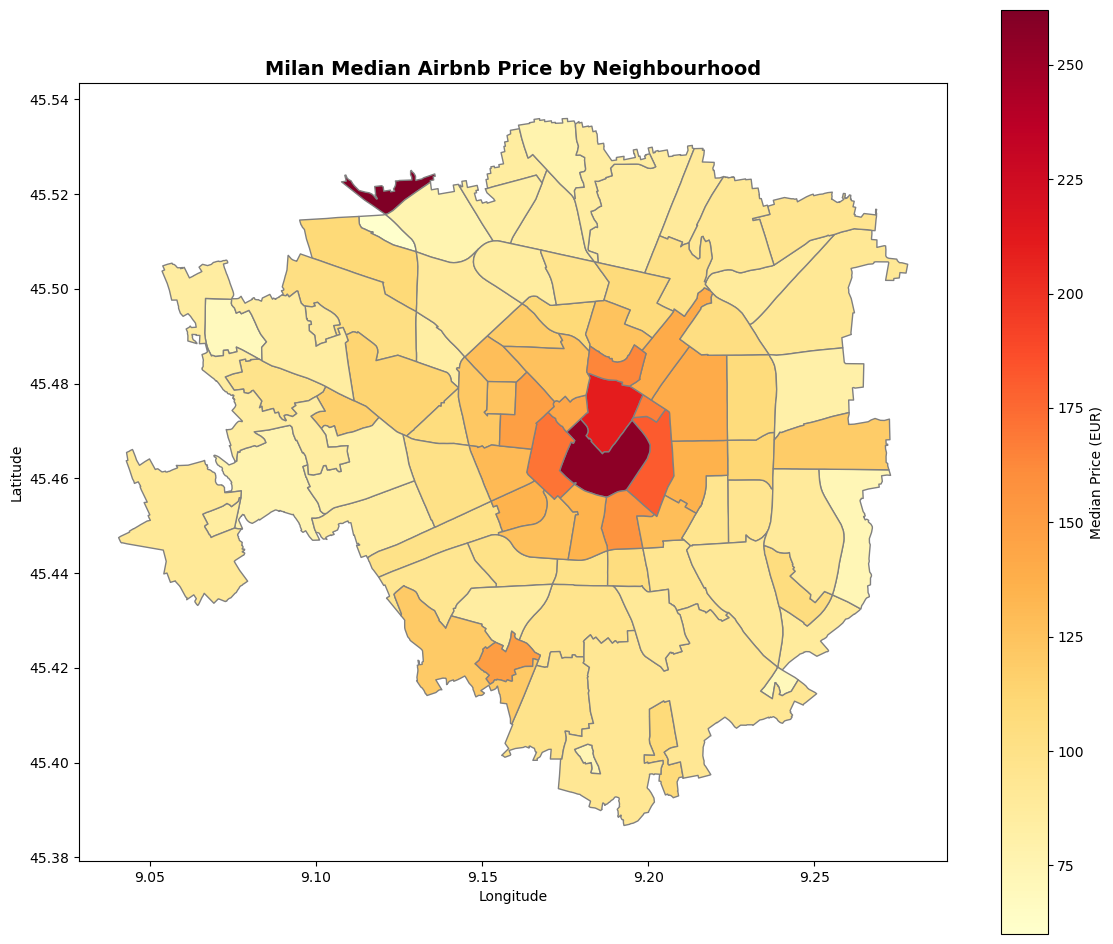

In [19]:
fig, ax = plt.subplots(figsize=(14, 12))

neighbourhoods_enriched.plot(
    ax=ax,
    column='median_price',
    cmap='YlOrRd',
    legend=True,
    legend_kwds={'label': 'Median Price (EUR)', 'orientation': 'vertical'},
    edgecolor='gray'
)

ax.set_title(f'{CITY_NAME} Median Airbnb Price by Neighbourhood', fontsize=14, fontweight='bold')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.savefig(project_root / 'reports' / 'figures' / f'fig_{CITY_NAME.lower()}_neighbourhood_median_price.png', dpi=150, bbox_inches='tight')
plt.show()

## Pipeline Complete

The data preparation is complete. Next steps:
1. Run `scripts/01_verify_spatial_data.py` to verify processed data
2. Run `scripts/03_ols_price_analysis.py` for OLS regression
3. Run `scripts/04_spatial_autocorr_morans_i.py` for Moran's I
4. Run `scripts/05_lm_diagnostic_tests.py` for LM diagnostics
5. Run `scripts/07_spatial_models_sar_sem.py` for spatial models